# Session 1 - Using Reynolds Equation for a Smooth Inlet
*By Robin Furze and Joshua Montgomery*

This session will introduce the basic theory and mathematics required to find the pressure induced at a smooth inlet. Later sessions in this Heterogeneous Multiscale Methods (HMM) workshop will of course introduce the surface roughness and multiscale solution frameworks. For now, this simple problem is used to introduce the basic theory.

The first four sessions will all cover a converging inlet with a forced fluid flow. This is because it is common flow scenario and it is  simple. Macroscale cavitation can be neglected as there is no diverging section. Cavitation is easy to introduce into this framework, but inital sessions will cover the simplest possible implementation of the HMM. Both ends of the inlet will be at atmoshpheric pressure. Pressure is introduced in the lubricant solely due to the flowing lubricant being forced through a converging inlet.


---
### Downloading the Necessary Packages

Many different solvers can be used. In this workshope, NGSOLVE is used. This is because it solves quickly and can be installed into a Google Colab environment. When the following code snippet may take a while to run initally, NGSOLVE will only need to be installed once. The first execution will take 90 seconds. Subsequent executions will take a second.

In [16]:
from IPython.core.display import clear_output
try:
    import ngsolve
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/ngsolve-install-release-real.sh" -O "/tmp/ngsolve-install.sh" && bash "/tmp/ngsolve-install.sh"
    import ngsolve

from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import *
from ngsolve.solvers import *

import numpy as np

import matplotlib.pyplot as plt

---
### Inputs

Various parameters are arbitrarily defined for this example. Feel free to tweak these parameters. These parameters are uniform across sessions.

In [17]:
## Physical Parameters
U = 2 #Fluid velocity (m/s)
eta = 0.1 # Fluid viscosity (Pa.s)
rho = 1 # Fluid density (kgm^-3)
h0 = 0.2 # Inital film thickness (m)
dhdx = 0.15 # Total reduction in film thickness across the inlet (m)

---
### Application of a 1D Mesh
Meshing a 1 dimensional inlet is trivial. In more complicated scenarios the mesh can be tailored as required. For example, point contact HMM models will have increased mesh resolution around the contact.

In [18]:
## Meshing Parameters
k = 1 # Order of elements
Ne = 100 # Number of elements

## Create mesh
mesh = Make1DMesh(Ne)

---
### Setup the Problem
Several equations/functions are initialised in the following section. Each will be explained here.

**Film Thickness Function** - this function will map the variation in film thickness to the x parameter. Hence as x increases the film will decrease.

**Pressure field** - a one dimesnional pressure field is initalised. This pressure field has Dirlecht boundary conditions applied to either end such that p=0.

**Assemble Reynolds Equation** - the Reynolds equation is assembled for solution in the next step.

In [19]:
# Film thickness function
def hg(x, h0, dhdx):
  return h0 - dhdx*x

# Pressure field
# Create a H1, order k space for the pressure field
V = H1(mesh, order=k, dirichlet=".*") # All boundaries are set to dirichlet, p = 0.
p = V.TrialFunction()  # Pressure trial function
v = V.TestFunction()   # Pressure test function
gfu = GridFunction(V)  # solution

#Reynolds Equation
a = BilinearForm(V)
# a += grad(p)*grad(v)*dx - x*v*dx
h = hg(x, h0, dhdx)
a += (h**3 / (12*eta)) * grad(p) * grad(v) * dx - U * h * grad(v) * dx
a.Assemble()


---
### Solve and Plot Outputs
The following section will solve for pressure using the Newton Solver within NGSOLVE. Outputs of film thickness and pressure are then plotted.

Pmax: 35.988
Hmin: 0.050
Integral of pressure: 19.861


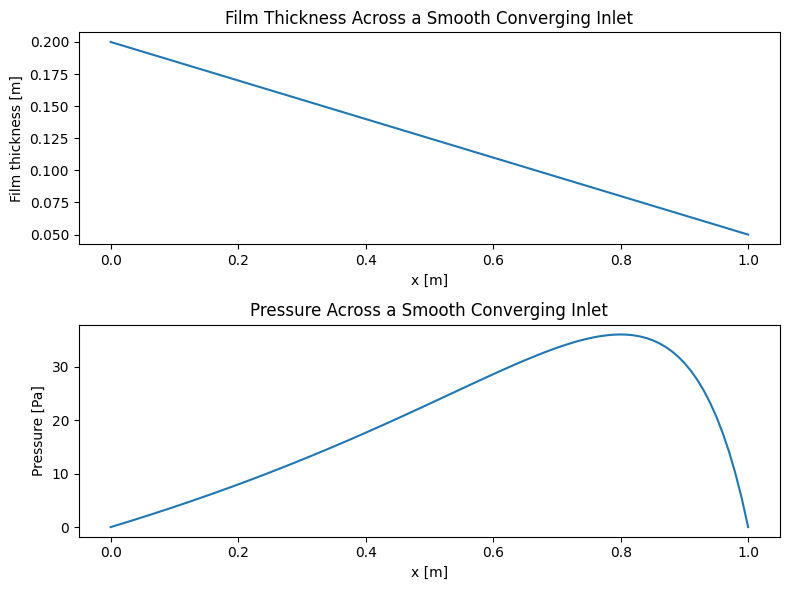

In [20]:

Newton(
    a,
    gfu,
    freedofs=V.FreeDofs(),
    maxit=100,
    maxerr=1e-4,
    inverse="sparsecholesky",
    printing=False,
)

Draw(gfu);


film_gridfunction = GridFunction(V)
film_gridfunction.Set(h)

# Create an x-value array for plotting
x_vals = np.linspace(0, 1, np.size(film_gridfunction.vec.data))

print(f'Pmax: {np.max(gfu.vec.data):.3f}')
print(f'Hmin: {np.min(film_gridfunction.vec.data):.3f}')
#calculate integral of pressure
integral = np.trapezoid(gfu.vec.data, x_vals)
print(f'Integral of pressure: {integral:.3f}')


fig, axes = plt.subplots(2, 1, figsize=(8, 6))

axes[0].plot(x_vals, film_gridfunction.vec.data)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("Film thickness [m]")
axes[0].set_title("Film Thickness Across a Smooth Converging Inlet")

axes[1].plot(x_vals, gfu.vec.data)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("Pressure [Pa]")
axes[1].set_title("Pressure Across a Smooth Converging Inlet")

plt.tight_layout()
plt.show()
